# Evaluación 1 — Calidad y Preparación de Datos para IA
**Universidad del Bío-Bío · Inteligencia Artificial · Prof. Jazna Meza Hidalgo**

Integrantes: _[completar nombres y correos]_

Proceso reproducible de diagnóstico, exploración, tratamiento y exportación del set `rendimiento_academico_evaluacion.csv`.

## Carga del set de datos
Se descarga con `wget`. **Cambiar la URL** por el enlace RAW del CSV del grupo.

In [ ]:
import os
URL = "https://RAW-DEL-GRUPO/rendimiento_academico_evaluacion.csv"
ARCHIVO = "rendimiento_academico_evaluacion.csv"
if not os.path.exists(ARCHIVO):
    !wget -q -O "$ARCHIVO" "$URL"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
pd.set_option("display.max_columns", None)
sns.set_theme(style="ticks", palette="mako")
plt.rcParams["figure.dpi"] = 110

datos = pd.read_csv(ARCHIVO)
datos_orig = datos.copy()          # respaldo intacto para la comparación final
print("Set cargado:", datos.shape)
datos.head()

Set cargado: (5100, 11)


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


### Definiciones globales

In [3]:
ID = "StudentID"
OBJETIVO = "FinalGrade"
COLS_NUM = ["Age","StudyHours","Attendance","PreviousGPA","AssignmentsCompleted","SleepHours","InternetHours"]
COLS_CAT = ["Scholarship","Program"]
# Rangos válidos por dominio (para diagnóstico y tratamiento)
RANGOS = {"Age":(15,80),"StudyHours":(0,168),"Attendance":(0,100),"PreviousGPA":(1,10),
          "AssignmentsCompleted":(0,100),"SleepHours":(0,24),"InternetHours":(0,24),"FinalGrade":(1,10)}

---
# 1. Diagnóstico de calidad

## 1.1 Caracterización

In [4]:
print("Registros :", datos.shape[0])
print("Variables :", datos.shape[1])
print("\nTipos:\n", datos.dtypes, sep="")
print("\nNuméricas   :", COLS_NUM)
print("Categóricas :", COLS_CAT)
print("Identificador:", ID, "| Objetivo:", OBJETIVO, "(escala 1–10)")

Registros : 5100
Variables : 11

Tipos:
StudentID                   str
Age                     float64
StudyHours              float64
Attendance              float64
PreviousGPA             float64
AssignmentsCompleted    float64
SleepHours              float64
InternetHours           float64
Scholarship                 str
Program                     str
FinalGrade              float64
dtype: object

Numéricas   : ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours']
Categóricas : ['Scholarship', 'Program']
Identificador: StudentID | Objetivo: FinalGrade (escala 1–10)


## 1.2 Valores faltantes

In [5]:
tab_falt = pd.DataFrame({"n": datos.isna().sum(), "pct": (datos.isna().mean()*100).round(2)})
tab_falt = tab_falt[tab_falt.n > 0].sort_values("n", ascending=False)
print("Total de celdas faltantes:", int(datos.isna().sum().sum()))
tab_falt

Total de celdas faltantes: 1335


,n,pct
Attendance,224,4.39
AssignmentsCompleted,216,4.24
StudyHours,181,3.55
InternetHours,176,3.45
PreviousGPA,162,3.18
SleepHours,122,2.39
Age,103,2.02
Scholarship,81,1.59
Program,70,1.37


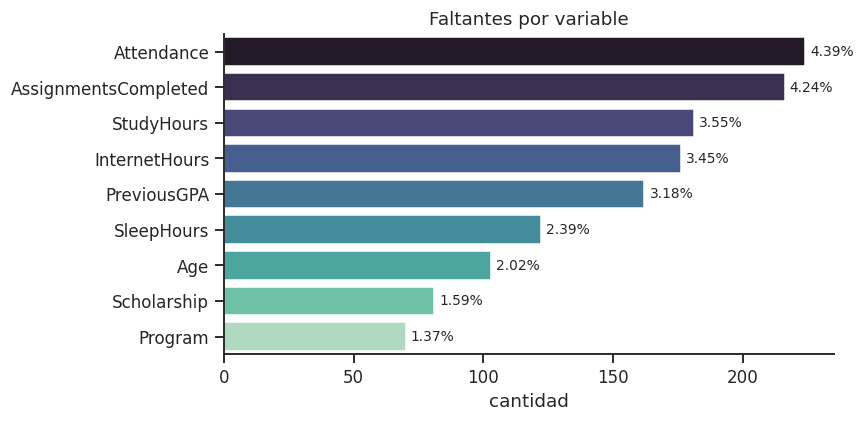

In [6]:
plt.figure(figsize=(8,4))
sns.barplot(y=tab_falt.index, x=tab_falt.n, hue=tab_falt.index, palette="mako", legend=False)
for i,(n,p) in enumerate(zip(tab_falt.n, tab_falt.pct)): plt.text(n+2, i, f"{p}%", va="center", fontsize=9)
plt.title("Faltantes por variable"); plt.xlabel("cantidad"); plt.ylabel(""); sns.despine(); plt.tight_layout(); plt.show()

**Lectura:** todas las variables (salvo `StudentID` y `FinalGrade`) tienen faltantes, ninguna sobre el 5%. Como la proporción es baja, conviene **imputar** en lugar de descartar filas. *Criterio:* mediana en numéricas (resistente a valores extremos) y moda en categóricas.

## 1.3 Registros duplicados

In [7]:
print("Duplicados exactos :", int(datos.duplicated().sum()), f"({datos.duplicated().mean()*100:.1f}%)")
print("StudentID repetidos:", int(datos.duplicated(subset=[ID]).sum()))

Duplicados exactos : 100 (2.0%)
StudentID repetidos: 100


**Lectura:** hay **100 filas idénticas (2%)**; `StudentID` es la clave que identifica un registro. *Decisión:* eliminarlas, ya que duplican información y distorsionan cualquier estadístico.

## 1.4 Inconsistencias

In [8]:
print("Categóricas — variantes de escritura:")
for c in COLS_CAT: print(f"  {c}: {dict(datos[c].value_counts(dropna=False))}")
print("\nNuméricas — valores fuera de dominio:")
inconsist = 0
for c,(lo,hi) in RANGOS.items():
    n = int(((datos[c]<lo)|(datos[c]>hi)).sum())
    if n: print(f"  {c:22s} fuera de [{lo},{hi}] -> {n}"); inconsist += n
print("\nTotal inconsistencias:", inconsist)

Categóricas — variantes de escritura:
  Scholarship: {'No': np.int64(3364), 'Sí': np.int64(1620), nan: np.int64(81), 'si': np.int64(10), 'No ': np.int64(10), 'NO': np.int64(8), 'SÍ ': np.int64(5), 'SI': np.int64(2)}
  Program: {'Ingeniería Informática': np.int64(1424), 'Ingeniería Industrial': np.int64(1119), 'Ingeniería Civil': np.int64(1004), 'Administración': np.int64(787), 'Contador Auditor': np.int64(660), nan: np.int64(70), 'Ingenieria Informatica': np.int64(10), 'INGENIERÍA INFORMÁTICA': np.int64(7), 'Ingeniería Civil ': np.int64(5), 'Ingeniería informática ': np.int64(4), 'INGENIERÍA CIVIL': np.int64(4), 'ADMINISTRACIÓN ': np.int64(3), 'Administracion': np.int64(3)}

Numéricas — valores fuera de dominio:
  Attendance             fuera de [0,100] -> 20
  SleepHours             fuera de [0,24] -> 8
  InternetHours          fuera de [0,24] -> 31
  FinalGrade             fuera de [1,10] -> 4

Total inconsistencias: 63


**Lectura:** dos tipos de inconsistencia — (1) **categóricas** con la misma clase escrita distinto (`si/Sí/SÍ`, `Ingenieria Informatica/INGENIERÍA INFORMÁTICA`); (2) **numéricas imposibles** (`Attendance`>100, horas negativas o >24) y el **target inválido** (notas <1). *Criterio:* unificar la ortografía; el target inválido se **elimina** (nunca se imputa el objetivo); las features inválidas pasan a `NaN` para imputarse.

## 1.5 Valores atípicos

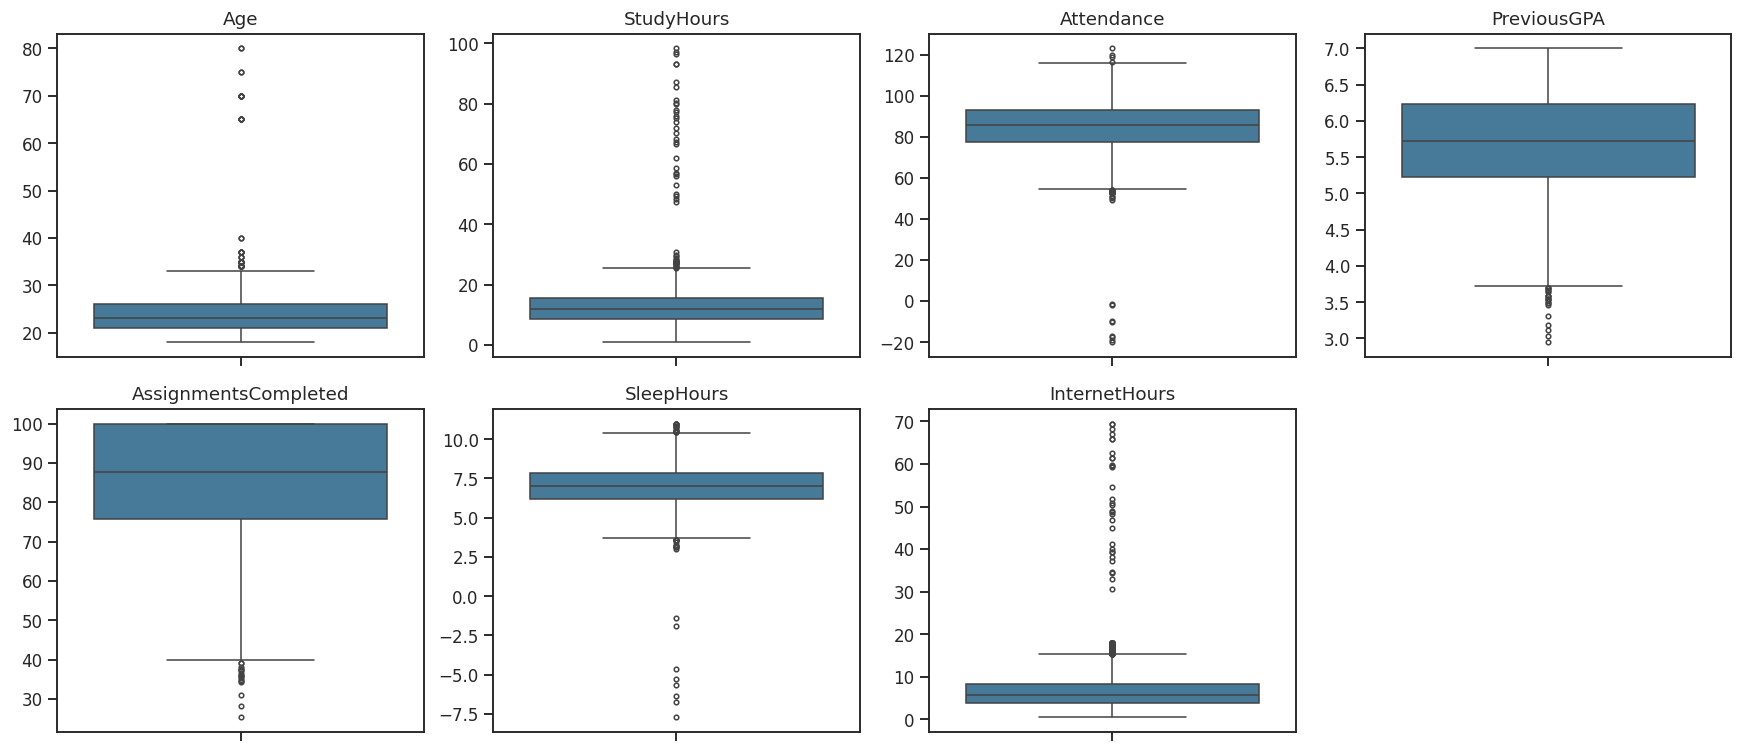

,variable,n_atipicos,pct
6,InternetHours,145,2.94
0,Age,63,1.26
1,StudyHours,49,1.00
5,SleepHours,34,0.68
2,Attendance,27,0.55
3,PreviousGPA,21,0.43
4,AssignmentsCompleted,17,0.35


In [9]:
# Detección con regla IQR + boxplots
fig, axes = plt.subplots(2, 4, figsize=(16,7))
det = []
for ax,c in zip(axes.ravel(), COLS_NUM):
    sns.boxplot(y=datos[c], ax=ax, color="#3a7ca5", fliersize=3); ax.set_title(c); ax.set_ylabel("")
    q1,q3 = datos[c].quantile([.25,.75]); iqr=q3-q1
    n = int(((datos[c]<q1-1.5*iqr)|(datos[c]>q3+1.5*iqr)).sum())
    det.append([c, n, round(n/datos[c].notna().sum()*100,2)])
axes.ravel()[-1].axis("off"); plt.tight_layout(); plt.show()
pd.DataFrame(det, columns=["variable","n_atipicos","pct"]).sort_values("n_atipicos", ascending=False)

**Lectura:** hay atípicos en todas las numéricas. Es clave **distinguir**: los valores *imposibles* (asistencia negativa, horas >24) son **inválidos** y ya se tratan como inconsistencias; los *extremos legítimos* (estudiantes con muchas horas de estudio) son datos reales.

*Criterio de este trabajo:* **no eliminar ni distorsionar** — se aplica un **winsorizing suave por percentiles (P1–P99)** en el dataset legible, y en el modelamiento se usa un **escalador robusto (`RobustScaler`)**, que centra en la mediana y escala por IQR, de modo que los extremos no dominan el escalado.

---
# 2. Análisis Exploratorio (EDA)
Se explora sobre datos depurados de duplicados, targets inválidos e inconsistencias de dominio (imputados), **conservando los atípicos legítimos** para observar las relaciones reales.

In [10]:
import unicodedata
def limpia_beca(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    return "Sí" if s.startswith("s") else ("No" if s.startswith("n") else np.nan)
def limpia_programa(x):
    if pd.isna(x): return np.nan
    s = "".join(ch for ch in unicodedata.normalize("NFKD", str(x).strip()) if not unicodedata.combining(ch)).upper()
    tabla = {"INGENIERIA INFORMATICA":"Ingeniería Informática","INGENIERIA INDUSTRIAL":"Ingeniería Industrial",
             "INGENIERIA CIVIL":"Ingeniería Civil","ADMINISTRACION":"Administración","CONTADOR AUDITOR":"Contador Auditor"}
    return tabla.get(s, np.nan)

expl = datos.drop_duplicates().reset_index(drop=True)
expl = expl[expl[OBJETIVO].between(1,10)].reset_index(drop=True)
expl["Scholarship"] = expl["Scholarship"].map(limpia_beca)
expl["Program"]     = expl["Program"].map(limpia_programa)
for c,(lo,hi) in RANGOS.items():
    if c in COLS_NUM: expl.loc[~expl[c].between(lo,hi) & expl[c].notna(), c] = np.nan
for c in COLS_NUM: expl[c] = expl[c].fillna(expl[c].median())
for c in COLS_CAT: expl[c] = expl[c].fillna(expl[c].mode()[0])
print("Datos para EDA:", expl.shape)
expl[COLS_NUM+[OBJETIVO]].describe().T.round(2)

Datos para EDA: (4996, 11)


,count,mean,std,min,25%,50%,75%,max
Age,4996.0,23.79,4.63,18.00,21.00,23.00,26.00,80.00
StudyHours,4996.0,12.41,6.79,1.00,8.92,12.00,15.28,98.33
Attendance,4996.0,84.75,10.16,49.01,77.91,85.43,92.50,100.00
PreviousGPA,4996.0,5.71,0.72,2.95,5.24,5.73,6.21,7.00
AssignmentsCompleted,4996.0,85.31,13.93,25.34,76.42,87.73,99.70,100.00
SleepHours,4996.0,7.00,1.22,3.00,6.18,7.03,7.83,11.00
InternetHours,4996.0,6.37,3.43,0.50,3.85,5.80,8.19,18.00
FinalGrade,4996.0,4.17,0.99,1.00,3.51,4.23,4.87,8.01


## 2.1 Distribución de las numéricas

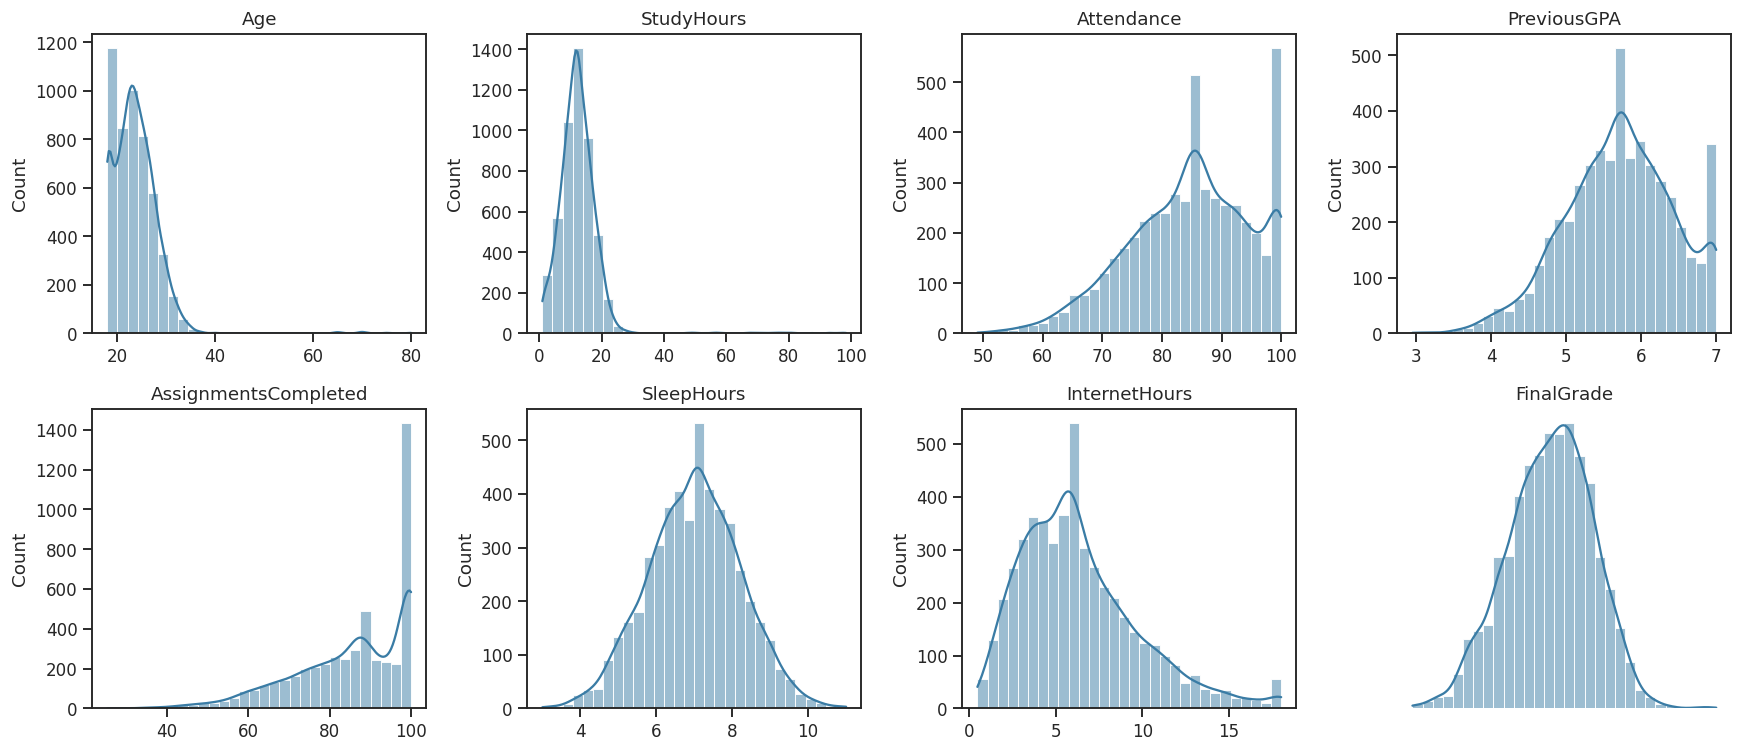

In [11]:
fig, axes = plt.subplots(2,4, figsize=(16,7))
for ax,c in zip(axes.ravel(), COLS_NUM+[OBJETIVO]):
    sns.histplot(expl[c], bins=30, kde=True, ax=ax, color="#3a7ca5"); ax.set_title(c); ax.set_xlabel("")
axes.ravel()[-1].axis("off"); plt.tight_layout(); plt.show()

**Interpretación:** las distribuciones son aproximadamente simétricas y unimodales; `FinalGrade` se centra cerca de 4.2 en la escala 1–10.

## 2.2 Distribución de las categóricas

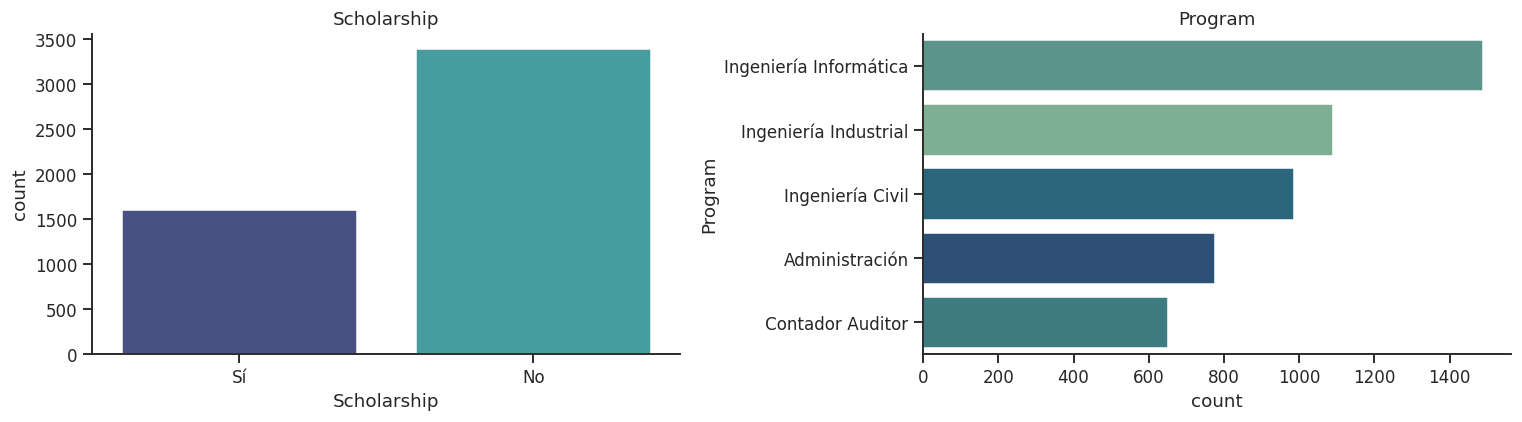

In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,4))
sns.countplot(data=expl, x="Scholarship", ax=axes[0], hue="Scholarship", palette="mako", legend=False); axes[0].set_title("Scholarship")
sns.countplot(data=expl, y="Program", ax=axes[1], hue="Program", palette="crest", legend=False,
              order=expl.Program.value_counts().index); axes[1].set_title("Program")
sns.despine(); plt.tight_layout(); plt.show()

**Interpretación:** predominan estudiantes **sin beca** (~2/3) y el programa más frecuente es Ingeniería Informática.

## 2.3 Correlaciones con FinalGrade

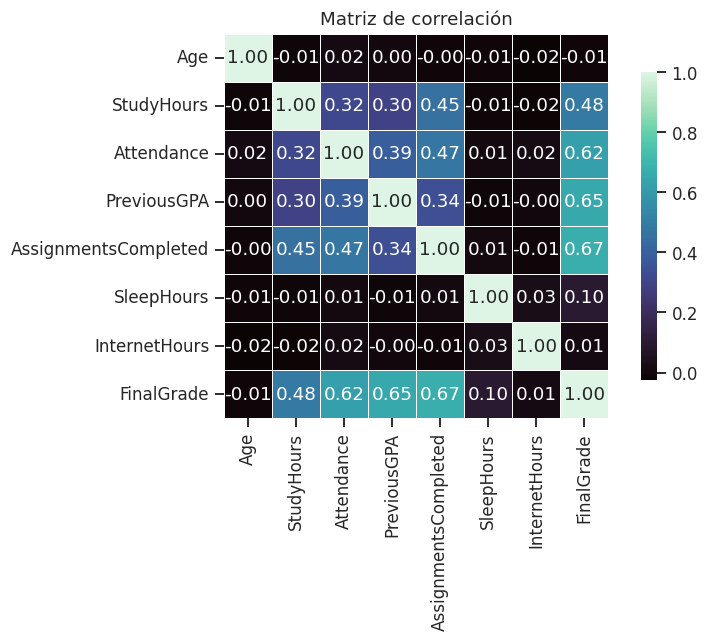

AssignmentsCompleted    0.673
PreviousGPA             0.649
Attendance              0.622
StudyHours              0.485
SleepHours              0.098
InternetHours           0.013
Age                    -0.007
Name: FinalGrade, dtype: float64

In [13]:
corr = expl[COLS_NUM+[OBJETIVO]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako", square=True, linewidths=.5, cbar_kws={"shrink":.8})
plt.title("Matriz de correlación"); plt.tight_layout(); plt.show()
corr[OBJETIVO].drop(OBJETIVO).sort_values(ascending=False).round(3)

**Interpretación:** las variables de esfuerzo académico (`AssignmentsCompleted`, `PreviousGPA`, `Attendance`) son las más asociadas a la nota; `SleepHours`, `InternetHours` y `Age` casi no correlacionan.

## Preguntas de investigación

### Pregunta 1 — Beca vs. sin beca

              mean    std  count
Scholarship                     
No           4.080  0.997   3394
Sí           4.371  0.930   1602

Dif (Sí-No)=0.291 | t=10.08, p=1.5e-23


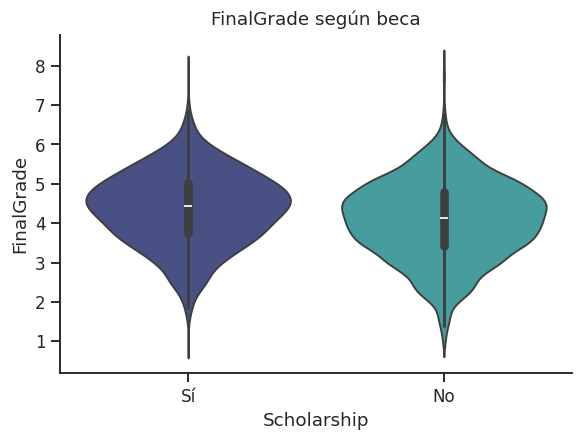

In [14]:
g1 = expl.groupby("Scholarship")[OBJETIVO].agg(["mean","std","count"]).round(3)
a,b = expl.loc[expl.Scholarship=="Sí",OBJETIVO], expl.loc[expl.Scholarship=="No",OBJETIVO]
t,pv = stats.ttest_ind(a,b,equal_var=False)
print(g1); print(f"\nDif (Sí-No)={a.mean()-b.mean():.3f} | t={t:.2f}, p={pv:.3g}")
plt.figure(figsize=(6,4)); sns.violinplot(data=expl, x="Scholarship", y=OBJETIVO, hue="Scholarship", palette="mako", legend=False)
plt.title("FinalGrade según beca"); sns.despine(); plt.show()

**Respuesta:** los **becados** promedian más (**≈4.37 vs. 4.08**, +0.29 puntos); diferencia significativa (p≈1e-23). El grupo con beca tiene el mayor promedio.

### Pregunta 2 — Programa académico

Program
Administración            4.232
Ingeniería Informática    4.219
Ingeniería Industrial     4.203
Ingeniería Civil          4.110
Contador Auditor          4.046
Name: FinalGrade, dtype: float64

Mayor=Administración (4.232) | Menor=Contador Auditor (4.046) | Dif=0.186 | ANOVA p=0.000208


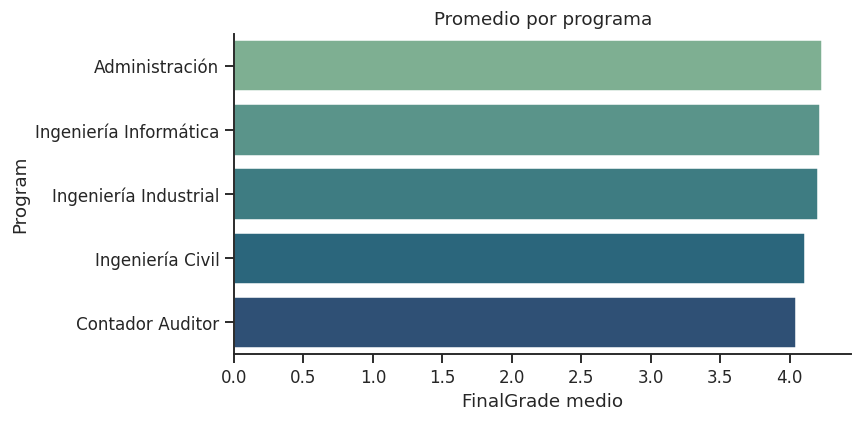

In [15]:
g2 = expl.groupby("Program")[OBJETIVO].mean().sort_values(ascending=False).round(3)
F,pf = stats.f_oneway(*[expl.loc[expl.Program==p,OBJETIVO] for p in expl.Program.unique()])
print(g2); print(f"\nMayor={g2.idxmax()} ({g2.max()}) | Menor={g2.idxmin()} ({g2.min()}) | Dif={g2.max()-g2.min():.3f} | ANOVA p={pf:.3g}")
plt.figure(figsize=(8,4)); sns.barplot(x=g2.values, y=g2.index, hue=g2.index, palette="crest", legend=False)
plt.xlabel("FinalGrade medio"); plt.title("Promedio por programa"); sns.despine(); plt.tight_layout(); plt.show()

**Respuesta:** el mayor promedio es **Administración (≈4.23)** y el menor **Contador Auditor (≈4.05)**; diferencia de **≈0.19 puntos** (ANOVA significativo). Las brechas entre programas son reales pero pequeñas.

### Pregunta 3 — StudyHours vs. FinalGrade

Pearson r=0.485 (p=1.64e-292) | Spearman=0.697


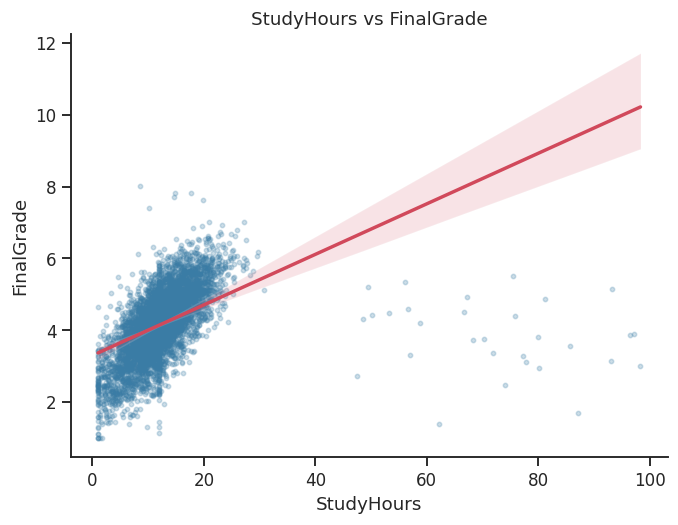

In [16]:
r,pr = stats.pearsonr(expl.StudyHours, expl[OBJETIVO]); rho,_ = stats.spearmanr(expl.StudyHours, expl[OBJETIVO])
print(f"Pearson r={r:.3f} (p={pr:.3g}) | Spearman={rho:.3f}")
plt.figure(figsize=(7,5))
sns.regplot(data=expl, x="StudyHours", y=OBJETIVO, scatter_kws={"s":8,"alpha":.25,"color":"#3a7ca5"}, line_kws={"color":"#d1495b"})
plt.title("StudyHours vs FinalGrade"); sns.despine(); plt.show()

**Respuesta:** relación **positiva moderada** (**r≈0.49**): a más horas de estudio, mejor nota, con dispersión en los valores altos.

### Pregunta 4 — Attendance vs. FinalGrade

Pearson r=0.622 (p=0)

tramo_asis
Baja     3.465
Media    4.210
Alta     4.846
Name: FinalGrade, dtype: float64


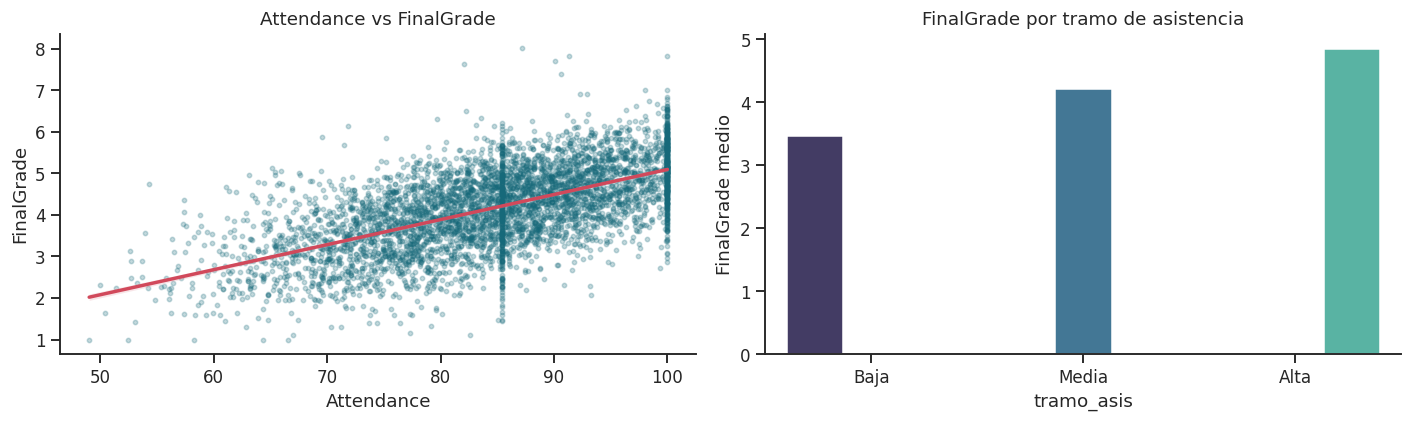

In [17]:
r2,pr2 = stats.pearsonr(expl.Attendance, expl[OBJETIVO])
expl["tramo_asis"] = pd.qcut(expl.Attendance, 3, labels=["Baja","Media","Alta"])
prom = expl.groupby("tramo_asis", observed=True)[OBJETIVO].mean().round(3)
print(f"Pearson r={r2:.3f} (p={pr2:.3g})\n"); print(prom)
fig,ax=plt.subplots(1,2,figsize=(13,4))
sns.regplot(data=expl, x="Attendance", y=OBJETIVO, ax=ax[0], scatter_kws={"s":8,"alpha":.25,"color":"#16697a"}, line_kws={"color":"#d1495b"})
ax[0].set_title("Attendance vs FinalGrade")
sns.barplot(x=prom.index, y=prom.values, ax=ax[1], hue=prom.index, palette="mako", legend=False)
ax[1].set_title("FinalGrade por tramo de asistencia"); ax[1].set_ylabel("FinalGrade medio")
sns.despine(); plt.tight_layout(); plt.show()

**Respuesta:** relación **positiva moderada** (**r≈0.62**). Asistencia **Alta** promedia **≈4.85** vs. **≈3.47** en asistencia **Baja** (+1.38 puntos): más asistencia, mejor rendimiento.

## Interpretación — tres conclusiones
1. **El esfuerzo académico explica el rendimiento:** tareas completadas, GPA previo y asistencia son los predictores más fuertes (r≈0.62–0.67); las horas de estudio aportan de forma moderada (≈0.49).

2. **Los factores demográficos y de estilo de vida no influyen:** edad, sueño e internet tienen correlación ≈0.

3. **Beca y programa importan poco:** su efecto (<0.3 puntos) es menor que el del esfuerzo académico.

---
# 3 y 4. Tratamiento e implementación con Pipeline
Decisiones fundamentadas en el diagnóstico (S1) y el EDA (S2).

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Limpieza a nivel de dato (previa al pipeline)
proc = datos_orig.drop_duplicates().reset_index(drop=True)
proc["Scholarship"] = proc["Scholarship"].map(limpia_beca)
proc["Program"]     = proc["Program"].map(limpia_programa)
for c,(lo,hi) in RANGOS.items():
    proc.loc[(proc[c]<lo)|(proc[c]>hi), c] = np.nan     # inválidos -> NaN (incluye target)
n_target = int(proc[OBJETIVO].isna().sum())
proc = proc.dropna(subset=[OBJETIVO]).reset_index(drop=True)   # target inválido -> se elimina
print(f"Target inválido eliminado: {n_target} filas | resultado: {proc.shape}")

X = proc.drop(columns=[ID, OBJETIVO])
y = proc[OBJETIVO]

Target inválido eliminado: 4 filas | resultado: (4996, 11)


**Estrategias:** duplicados→eliminar · target inválido→eliminar fila · inconsistencias→NaN · faltantes→mediana/moda · **atípicos→winsorizing P1–P99 (legible) y `RobustScaler` (modelo)** · categóricas→normalizadas.

### Dataset final legible (4996 × 11)

In [19]:
legible = proc.copy()   # conserva StudentID + features + FinalGrade (11 columnas)
for c in COLS_NUM: legible[c] = legible[c].fillna(legible[c].median())
for c in COLS_CAT: legible[c] = legible[c].fillna(legible[c].mode()[0])

# Winsorizing por percentiles 1–99 (acota extremos sin eliminar filas ni tocar el target)
n_acotados = 0
for c in COLS_NUM:
    lo, hi = legible[c].quantile([0.01, 0.99])
    n_acotados += int(((legible[c]<lo)|(legible[c]>hi)).sum())
    legible[c] = legible[c].clip(lo, hi).round(2)
legible[OBJETIVO] = legible[OBJETIVO].round(2)
print("Valores acotados por winsorizing P1–P99:", n_acotados)

assert legible.shape == (4996, 11) and legible.isna().sum().sum() == 0
legible.head()

Valores acotados por winsorizing P1–P99: 435


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,34.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


### Matriz de diseño para modelamiento (4996 × 14)
Numéricas: imputación → **RobustScaler** (robusto a atípicos). Categóricas: imputación → One-Hot. `StudentID` se descarta. El objetivo `y` se mantiene separado.

In [20]:
prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("esc", RobustScaler())]), COLS_NUM),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh",  OneHotEncoder(handle_unknown="ignore"))]), COLS_CAT),
], remainder="drop")
Xm = prep.fit_transform(X)
print("Matriz de diseño:", Xm.shape)
print(list(prep.get_feature_names_out()))

Matriz de diseño: (4996, 14)
['num__Age', 'num__StudyHours', 'num__Attendance', 'num__PreviousGPA', 'num__AssignmentsCompleted', 'num__SleepHours', 'num__InternetHours', 'cat__Scholarship_No', 'cat__Scholarship_Sí', 'cat__Program_Administración', 'cat__Program_Contador Auditor', 'cat__Program_Ingeniería Civil', 'cat__Program_Ingeniería Industrial', 'cat__Program_Ingeniería Informática']


---
# 5. Dataset final, validación y evidencia

In [21]:
assert legible.duplicated().sum()==0 and legible[OBJETIVO].between(1,10).all()
legible.to_csv("rendimiento_academico_limpio.csv", index=False)
print("Exportado rendimiento_academico_limpio.csv", legible.shape)

Exportado rendimiento_academico_limpio.csv (4996, 11)


## Comparación: original vs. tratado

In [22]:
def n_inval(d): return sum(int(((d[c]<lo)|(d[c]>hi)).sum()) for c,(lo,hi) in RANGOS.items())
tabla = pd.DataFrame({
    "Indicador":["Cantidad de registros","Cantidad de variables","Valores faltantes",
                 "Registros duplicados","Inconsistencias","Outliers tratados"],
    "Dataset original":[datos_orig.shape[0], datos_orig.shape[1], int(datos_orig.isna().sum().sum()),
                        int(datos_orig.duplicated().sum()), n_inval(datos_orig), 0],
    "Dataset tratado":[legible.shape[0], legible.shape[1], 0, 0, 0, n_acotados],
})
tabla

,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,4996
1,Cantidad de variables,11,11
2,Valores faltantes,1335,0
3,Registros duplicados,100,0
4,Inconsistencias,63,0
5,Outliers tratados,0,435


**Estado final:** el dataset tratado no presenta faltantes, duplicados ni inconsistencias, y los extremos quedaron acotados mediante winsorizing por percentiles.